In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

In [131]:
data=np.random.exponential(scale=2, size=1000)
df=pd.DataFrame({"Salary":data})

In [132]:
df.head()

,Salary
0,1.180180
1,2.722767
2,0.446650
3,0.296540
4,4.297396


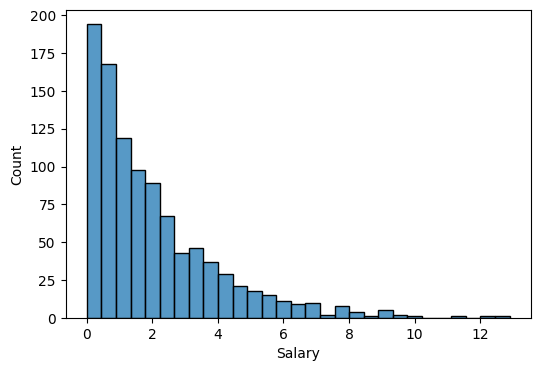

In [133]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary)
plt.show()

In [134]:
df.Salary.skew()

np.float64(1.6920559038246576)

In [135]:
df["updated_salary"], lambda_val=boxcox(df.Salary)

In [136]:
df.head()

,Salary,updated_salary
0,1.180180,0.169352
1,2.722767,1.146979
2,0.446650,-0.725813
3,0.296540,-1.039414
4,4.297396,1.779302


In [137]:
lambda_val

np.float64(0.2646780000076134)

In [138]:
df.updated_salary.skew()

np.float64(-0.05087427856603509)

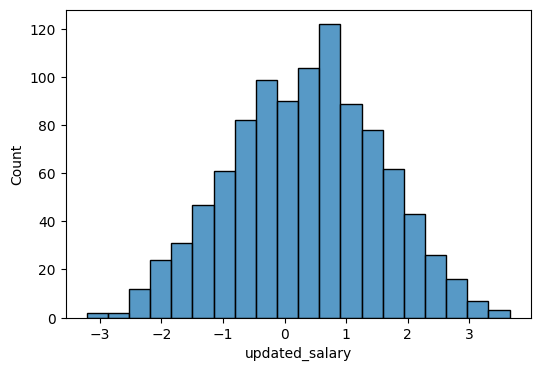

In [139]:
plt.figure(figsize=(6,4))
sns.histplot(df.updated_salary)
plt.show()

In [140]:
##left skewed distribution

In [141]:
data=np.random.exponential(scale=2, size=1000)
data= 10-data
df=pd.DataFrame({"Salary2":data})

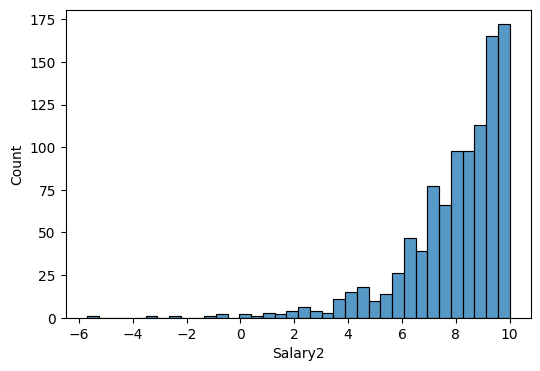

In [142]:
plt.figure(figsize=(6,4))
sns.histplot(df.Salary2)
plt.show()

In [143]:
df.Salary2.skew()

np.float64(-2.0012912351000987)

In [144]:
df["reflex_salary"]=(df.Salary2.max() - df.Salary2) + 1

In [145]:
df.head()

,Salary2,reflex_salary
0,9.729384,1.266100
1,9.635733,1.359751
2,4.033033,6.962451
3,7.562311,3.433173
4,9.767039,1.228445


In [146]:
max(df.reflex_salary) , min(df.reflex_salary)

(16.70321809059866, 1.0)

In [147]:
df["transformed_salary"]=np.log(df.reflex_salary)

In [148]:
df.transformed_salary.skew()

np.float64(0.3500381443932314)

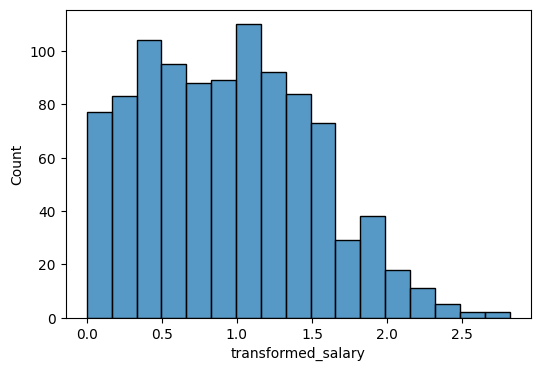

In [149]:
plt.figure(figsize=(6,4))
sns.histplot(df.transformed_salary)
plt.show()

In [150]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder


In [151]:
df = pd.read_csv("C:\\Users\\cngan\\Downloads\\test2.csv")

In [152]:
df

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,NaN,IT,62000.0
4,4,Eve,29.0,HR,NaN
5,5,Alice,25.0,HR,50000.0


In [153]:
df.shape

(6, 5)

In [154]:
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Salary"] = pd.to_numeric(df["Salary"], errors="coerce")

In [155]:
df.Age = df.Age.fillna(value = df.Age.mean())
df.Salary = df.Salary.fillna(value = df.Salary.mean())

In [156]:
df.Age.isna()

0    False
1    False
2    False
3    False
4    False
5    False
Name: Age, dtype: bool

In [157]:
df

,Unnamed: 0,Name,Age,Department,Salary
0,0,Alice,25.0,HR,50000.0
1,1,Bob,30.0,IT,60000.0
2,2,Charlie,35.0,Finance,70000.0
3,3,David,28.8,IT,62000.0
4,4,Eve,29.0,HR,58400.0
5,5,Alice,25.0,HR,50000.0


In [158]:
encoder = LabelEncoder()

In [159]:
df["tranformed_name"] = encoder.fit_transform(df.Name)

In [160]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,tranformed_name
0,0,Alice,25.0,HR,50000.0,0
1,1,Bob,30.0,IT,60000.0,1
2,2,Charlie,35.0,Finance,70000.0,2
3,3,David,28.8,IT,62000.0,3
4,4,Eve,29.0,HR,58400.0,4


In [161]:
encoder2 = OneHotEncoder(sparse_output=False)

In [162]:
encoded = encoder2.fit_transform(df[["Department"]])

In [163]:
encoder2.get_feature_names_out()

array(['Department_Finance', 'Department_HR', 'Department_IT'],
      dtype=object)

In [164]:
encoded

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [165]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler


In [166]:
scaler = StandardScaler()

In [167]:
df["scaled_salary"] = scaler.fit_transform(df[["Salary"]])

In [168]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,tranformed_name,scaled_salary
0,0,Alice,25.0,HR,50000.0,0,-1.205755
1,1,Bob,30.0,IT,60000.0,1,0.229668
2,2,Charlie,35.0,Finance,70000.0,2,1.665091
3,3,David,28.8,IT,62000.0,3,0.516752
4,4,Eve,29.0,HR,58400.0,4,0.000000


In [169]:
scaler = MinMaxScaler()

In [170]:
df["scaled_salary"] = scaler.fit_transform(df[["Salary"]])

In [171]:
df.head()

,Unnamed: 0,Name,Age,Department,Salary,tranformed_name,scaled_salary
0,0,Alice,25.0,HR,50000.0,0,0.00
1,1,Bob,30.0,IT,60000.0,1,0.50
2,2,Charlie,35.0,Finance,70000.0,2,1.00
3,3,David,28.8,IT,62000.0,3,0.60
4,4,Eve,29.0,HR,58400.0,4,0.42


In [172]:
import numpy as np
import pandas as pd

In [173]:
data = pd.read_csv("C:\\Users\\cngan\\Downloads\\data_visualization.csv")

In [174]:
data.head()

,Unnamed: 0,Student_ID,Name,Gender,Department,Age,Math_Score,Science_Score,Attendance_Percentage,Study_Hours_per_Week
0,0,1,Aarav,Male,CS,21,78,75,85,10
1,1,2,Diya,Female,IT,22,85,88,90,12
2,2,3,Rohan,Male,CS,20,90,85,95,15
3,3,4,Sneha,Female,ECE,21,67,70,80,8
4,4,5,Arjun,Male,IT,23,88,90,92,14


<Figure size 640x480 with 0 Axes>

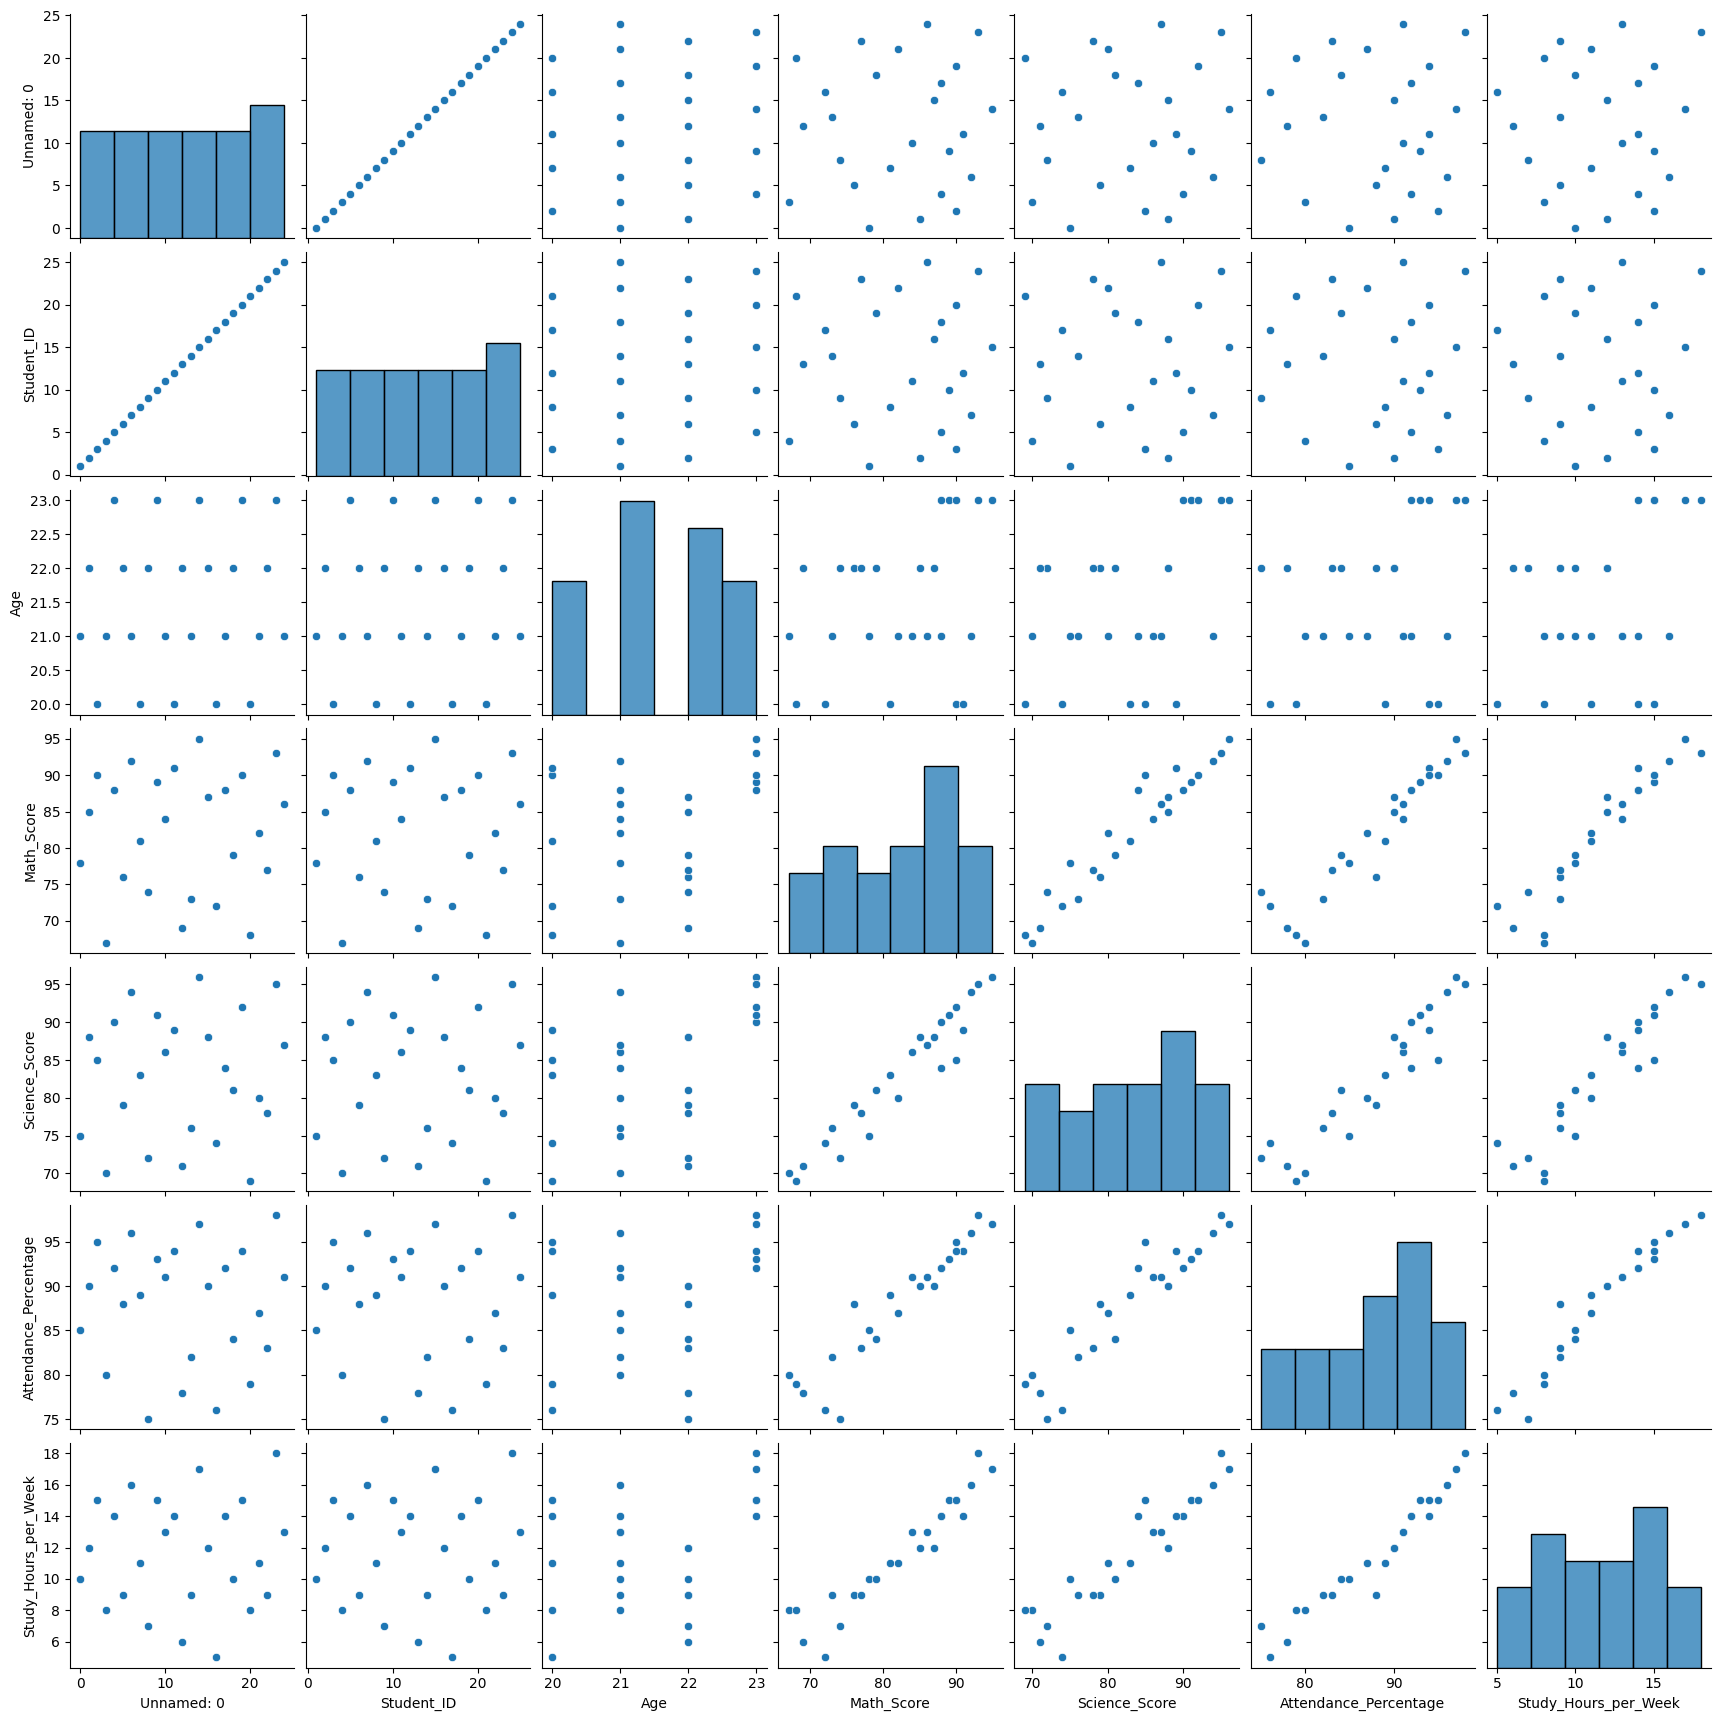

In [175]:
plt.figure()
sns.pairplot(data)

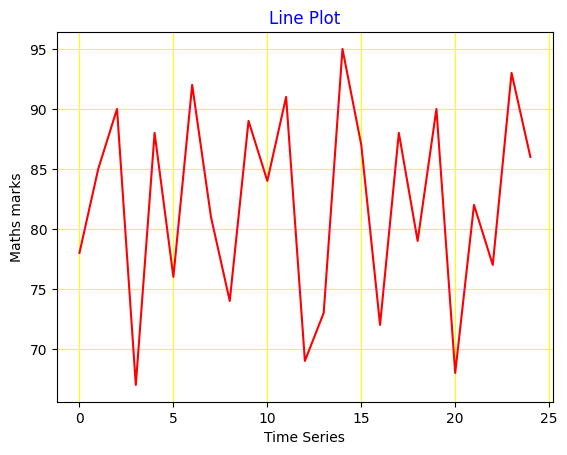

In [176]:
plt.plot(data.Math_Score , color="red")
plt.grid(color="yellow")
plt.title("Line Plot", color="blue")
plt.xlabel("Time Series")
plt.ylabel("Maths marks")
plt.show()


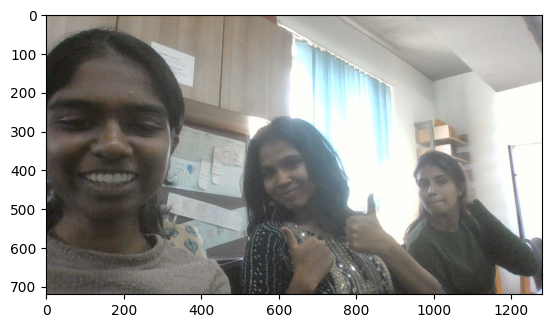

In [177]:
img = plt.imread("C:\\Users\\cngan\\OneDrive\\Pictures\\Camera Roll\\WIN_20260213_14_20_48_Pro.jpg")
plt.imshow(img)
plt.show()

In [178]:
import matplotlib.pyplot as plt
months = [1, 2, 3, 4, 5]
revenue = [2000, 4500, 4000, 7500, 9000]

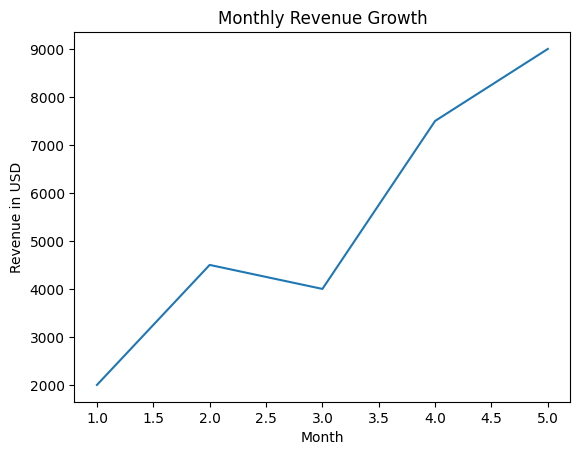

In [179]:
plt.plot(months, revenue)
plt.title("Monthly Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue in USD")
plt.show()

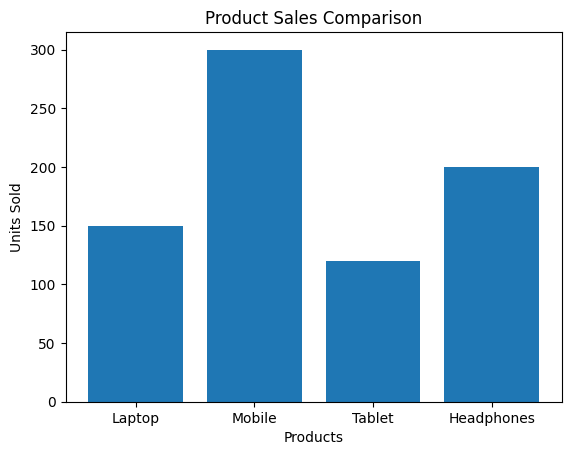

In [183]:
import matplotlib.pyplot as plt

products = ["Laptop", "Mobile", "Tablet", "Headphones"]
sales = [150, 300, 120, 200]

plt.bar(products, sales)
plt.title("Product Sales Comparison")
plt.xlabel("Products")
plt.ylabel("Units Sold")
plt.show()


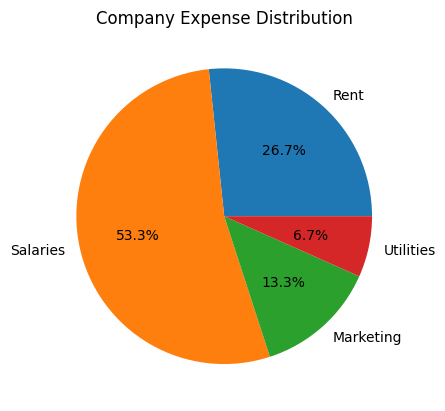

In [184]:
import matplotlib.pyplot as plt

categories = ["Rent", "Salaries", "Marketing", "Utilities"]
expenses = [40000, 80000, 20000, 10000]

plt.pie(expenses, labels=categories, autopct='%1.1f%%')
plt.title("Company Expense Distribution")
plt.show()


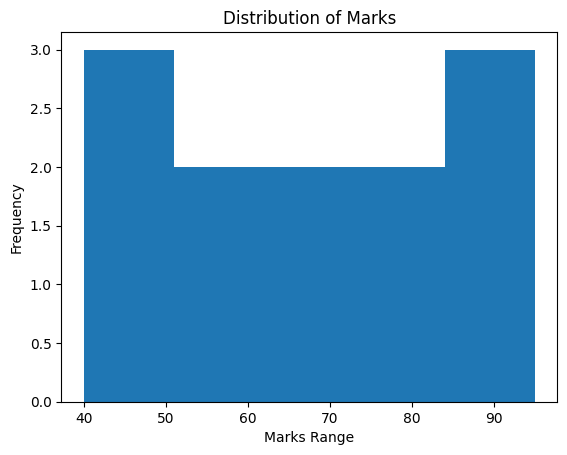

In [186]:
import matplotlib.pyplot as plt

marks = [45, 50, 67, 80, 90, 55, 60, 72, 88, 95, 40, 76]

plt.hist(marks, bins=5)
plt.title("Distribution of Marks")
plt.xlabel("Marks Range")
plt.ylabel("Frequency")
plt.show()


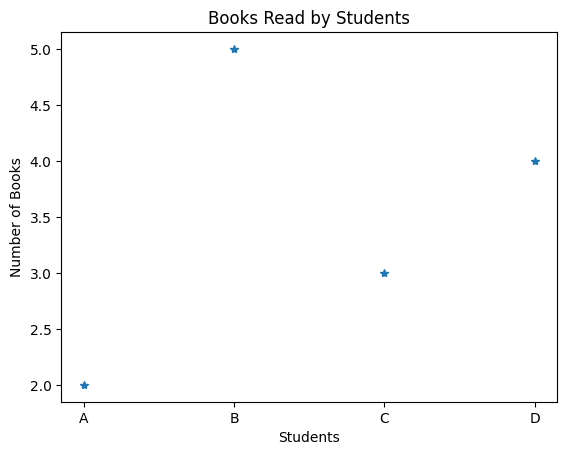

In [191]:
import matplotlib.pyplot as plt

students = ["A", "B", "C", "D"]
books_read = [2, 5, 3, 4]

plt.plot(students, books_read, marker='*', linestyle='None')
plt.title("Books Read by Students")
plt.xlabel("Students")
plt.ylabel("Number of Books")
plt.show()
